# EDA: рекомендации банковских продуктов

Анализ Santander Product Recommendation (`train_ver2.csv`).

**Выводы из EDA:**
- данные помесячные, один клиент может встречаться в нескольких месяцах;
- продукты сильно несбалансированы: текущий счёт и дебетовый счёт встречаются чаще всего;
- у части клиентов отсутствует `renta`, нужна imputation;
- для таргета используем **новые** продукты: `product_t = 1` и `product_{t-1} = 0`.

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

assert (ROOT / "src").exists(), f"Не найден src/. Запустите Jupyter из корня проекта или из notebooks/"
print("Project root:", ROOT)

Project root: /home/mle-user/mle-bank-recommendations


{
  "sample_date": "2015-06-28",
  "rows": 632110,
  "unique_clients": 632110,
  "missing_renta_share": 0.1715508376706586,
  "active_clients_share": 0.5495435920963123,
  "top_products": {
    "ind_cco_fin_ult1": 0.7815522614734777,
    "ind_ctop_fin_ult1": 0.16548069165176946,
    "ind_recibo_ult1": 0.15607251902358768,
    "ind_ecue_fin_ult1": 0.10140007277214409,
    "ind_cno_fin_ult1": 0.09467497745645537
  },
  "product_penetration_mean": 0.07465083872532734
}


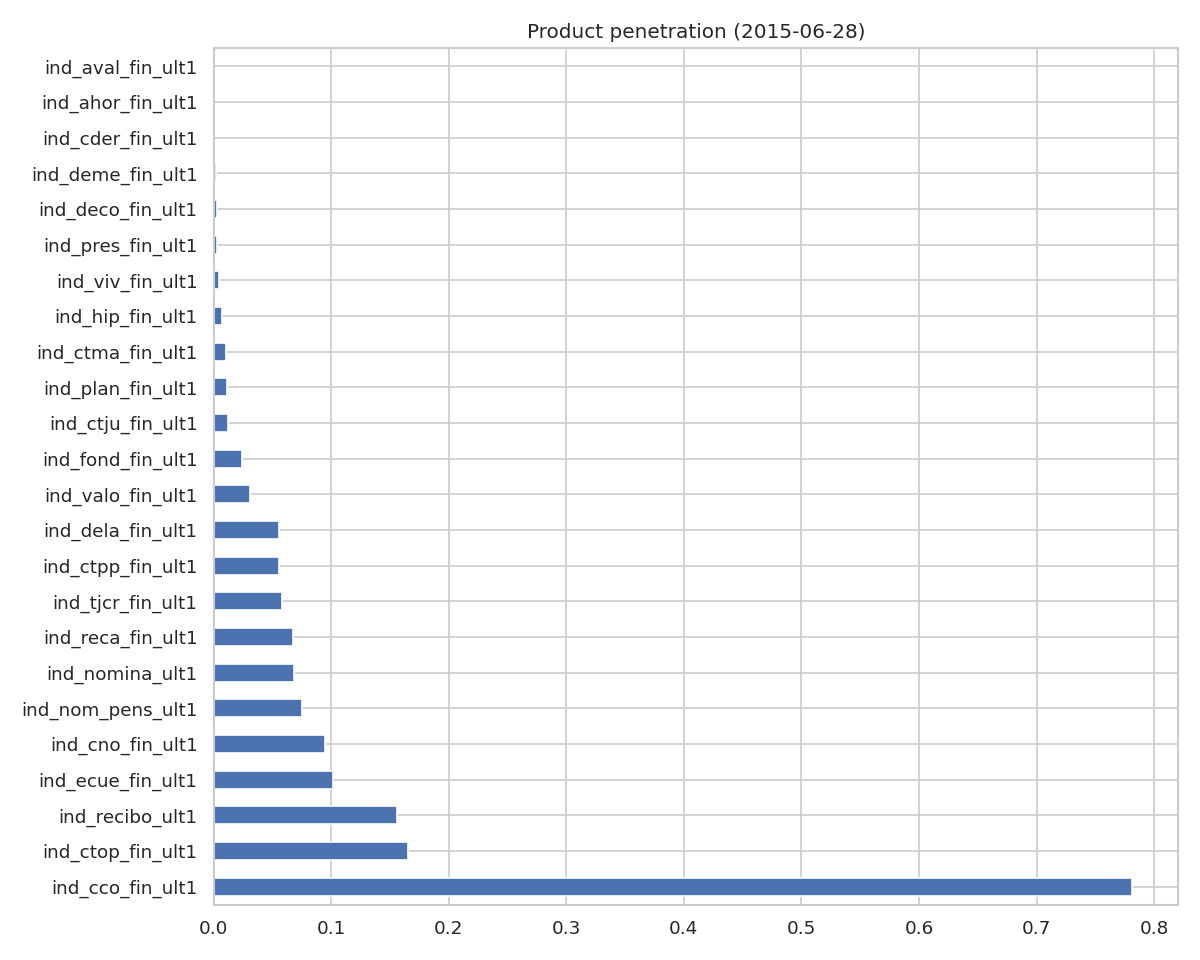

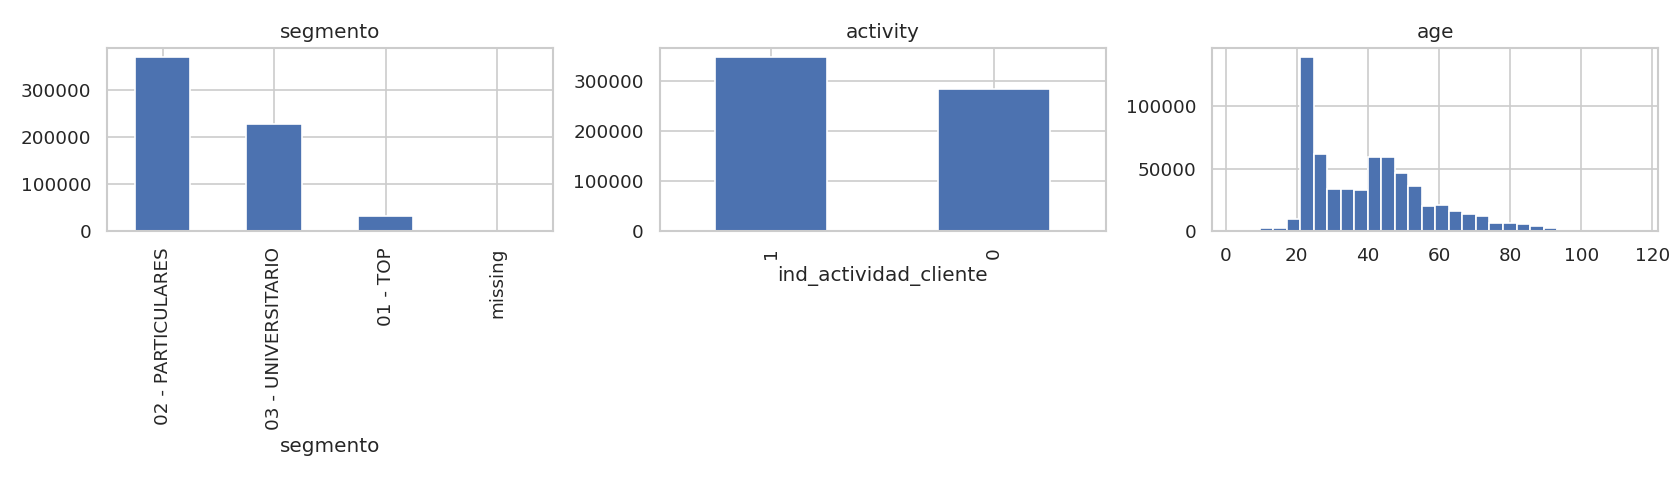

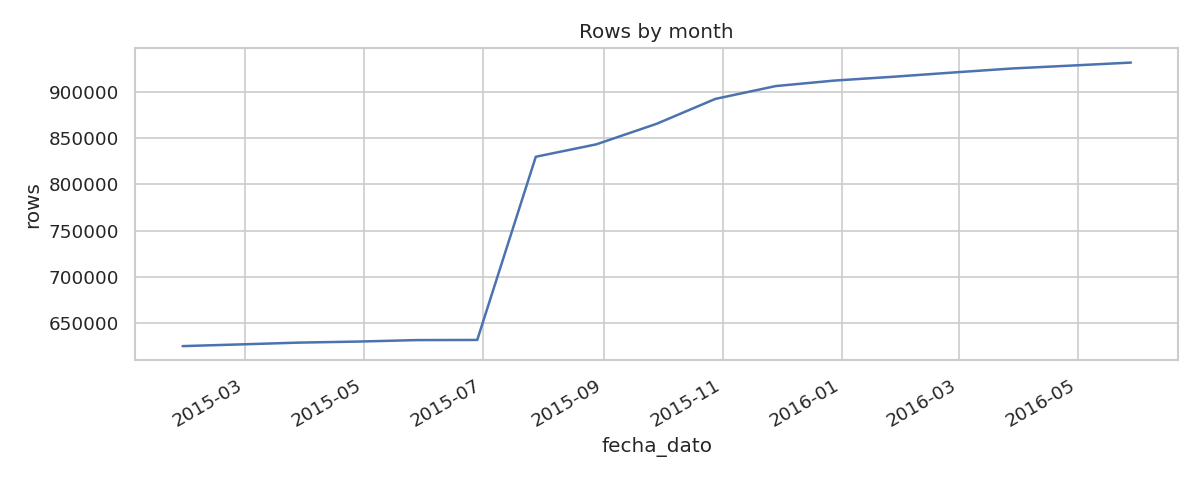

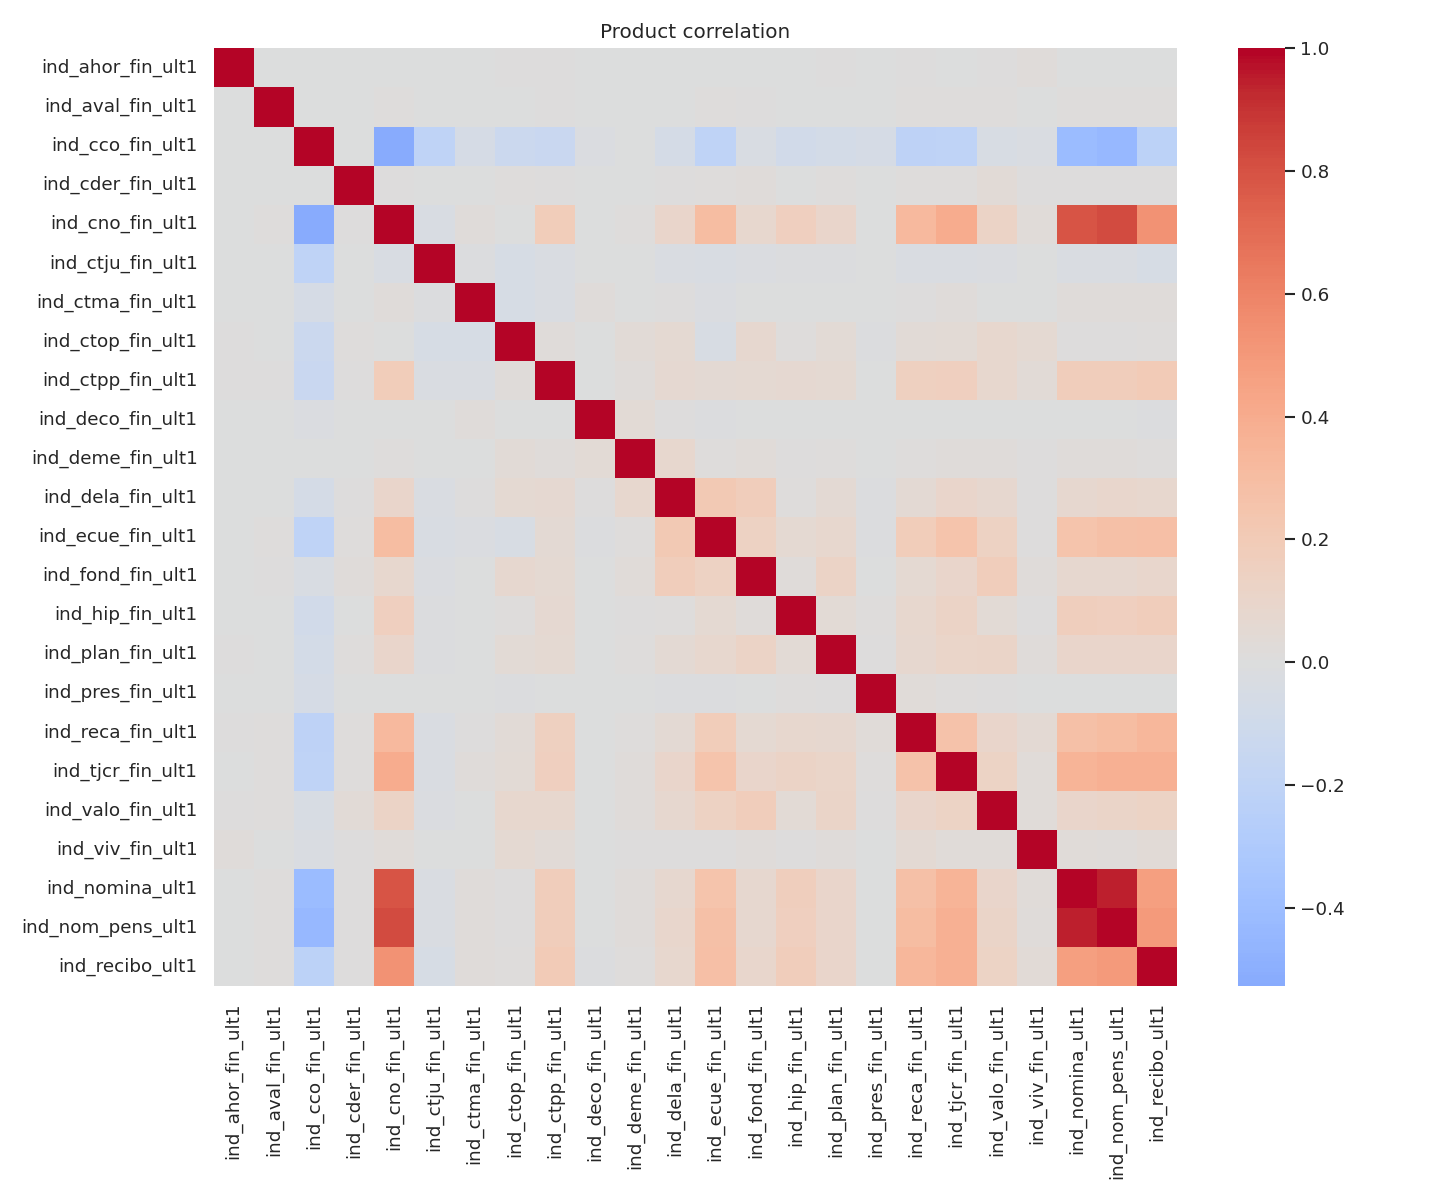

In [5]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from src.config import ARTIFACTS_DIR, PRODUCT_COLS
from src.data import load_month
from src.eda import run_eda

summary = run_eda()
display(Image(filename=str(ARTIFACTS_DIR / "eda" / "product_penetration.png")))
display(Image(filename=str(ARTIFACTS_DIR / "eda" / "client_segments.png")))
display(Image(filename=str(ARTIFACTS_DIR / "eda" / "monthly_rows.png")))
display(Image(filename=str(ARTIFACTS_DIR / "eda" / "product_correlation.png")))

In [6]:
sample = load_month("2015-06-28")
sample[PRODUCT_COLS].mean().sort_values(ascending=False).head(10)

ind_cco_fin_ult1     0.781552
ind_ctop_fin_ult1    0.165481
ind_recibo_ult1      0.156073
ind_ecue_fin_ult1    0.101400
ind_cno_fin_ult1     0.094675
ind_nom_pens_ult1    0.075466
ind_nomina_ult1      0.068855
ind_reca_fin_ult1    0.067849
ind_tjcr_fin_ult1    0.057822
ind_ctpp_fin_ult1    0.055911
dtype: float64